In [37]:
import scanpy as sc
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

In [3]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd.h5ad')

In [5]:
adata_mic = adata[adata.obs.cell_class == 'Microglia']

In [10]:
sc.tl.pca(adata_mic, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_mic, n_neighbors=20, n_pcs=30)  # tune n_pcs by variance ratio if you like
sc.tl.umap(adata_mic, min_dist=0.3, spread=1.0)

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: divide by zero encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: overflow encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/utils/sparsefuncs.py:736: RuntimeWarning: invalid value encountered in matmul
  matvec=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: divide by zero encountered in matmul
  matmat=lambda x: X @ x - offset @ x,
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/utils/sparsefuncs.py:737: RuntimeWarning: overflow encountered in matmul
  matmat=lambda x: X @ x - offset @ x,
/Users/christoffer

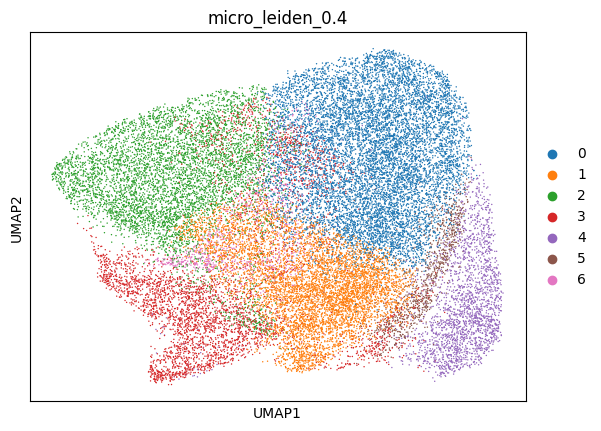

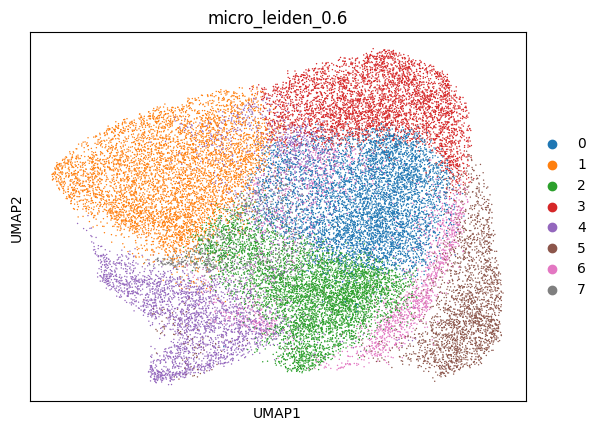

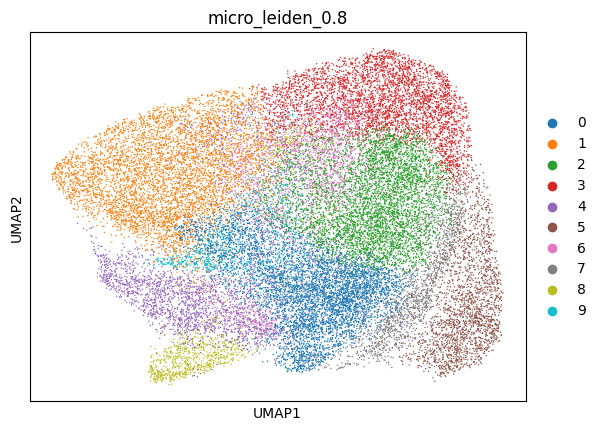

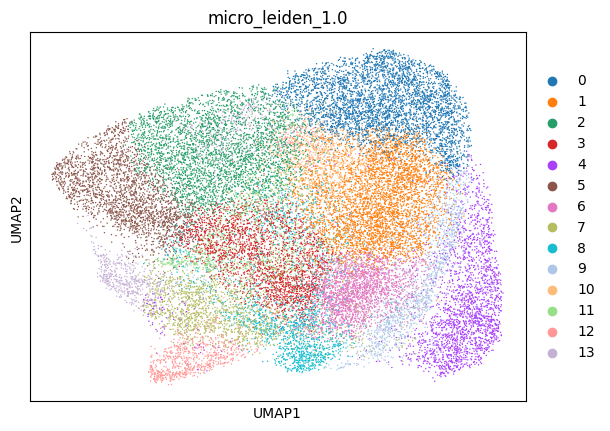

In [14]:
for res in [0.4, 0.6, 0.8, 1.0]:
    sc.tl.leiden(adata_mic, resolution=res, key_added=f"micro_leiden_{res}")
    sc.pl.umap(adata_mic, color = 'micro_leiden_'+str(res))

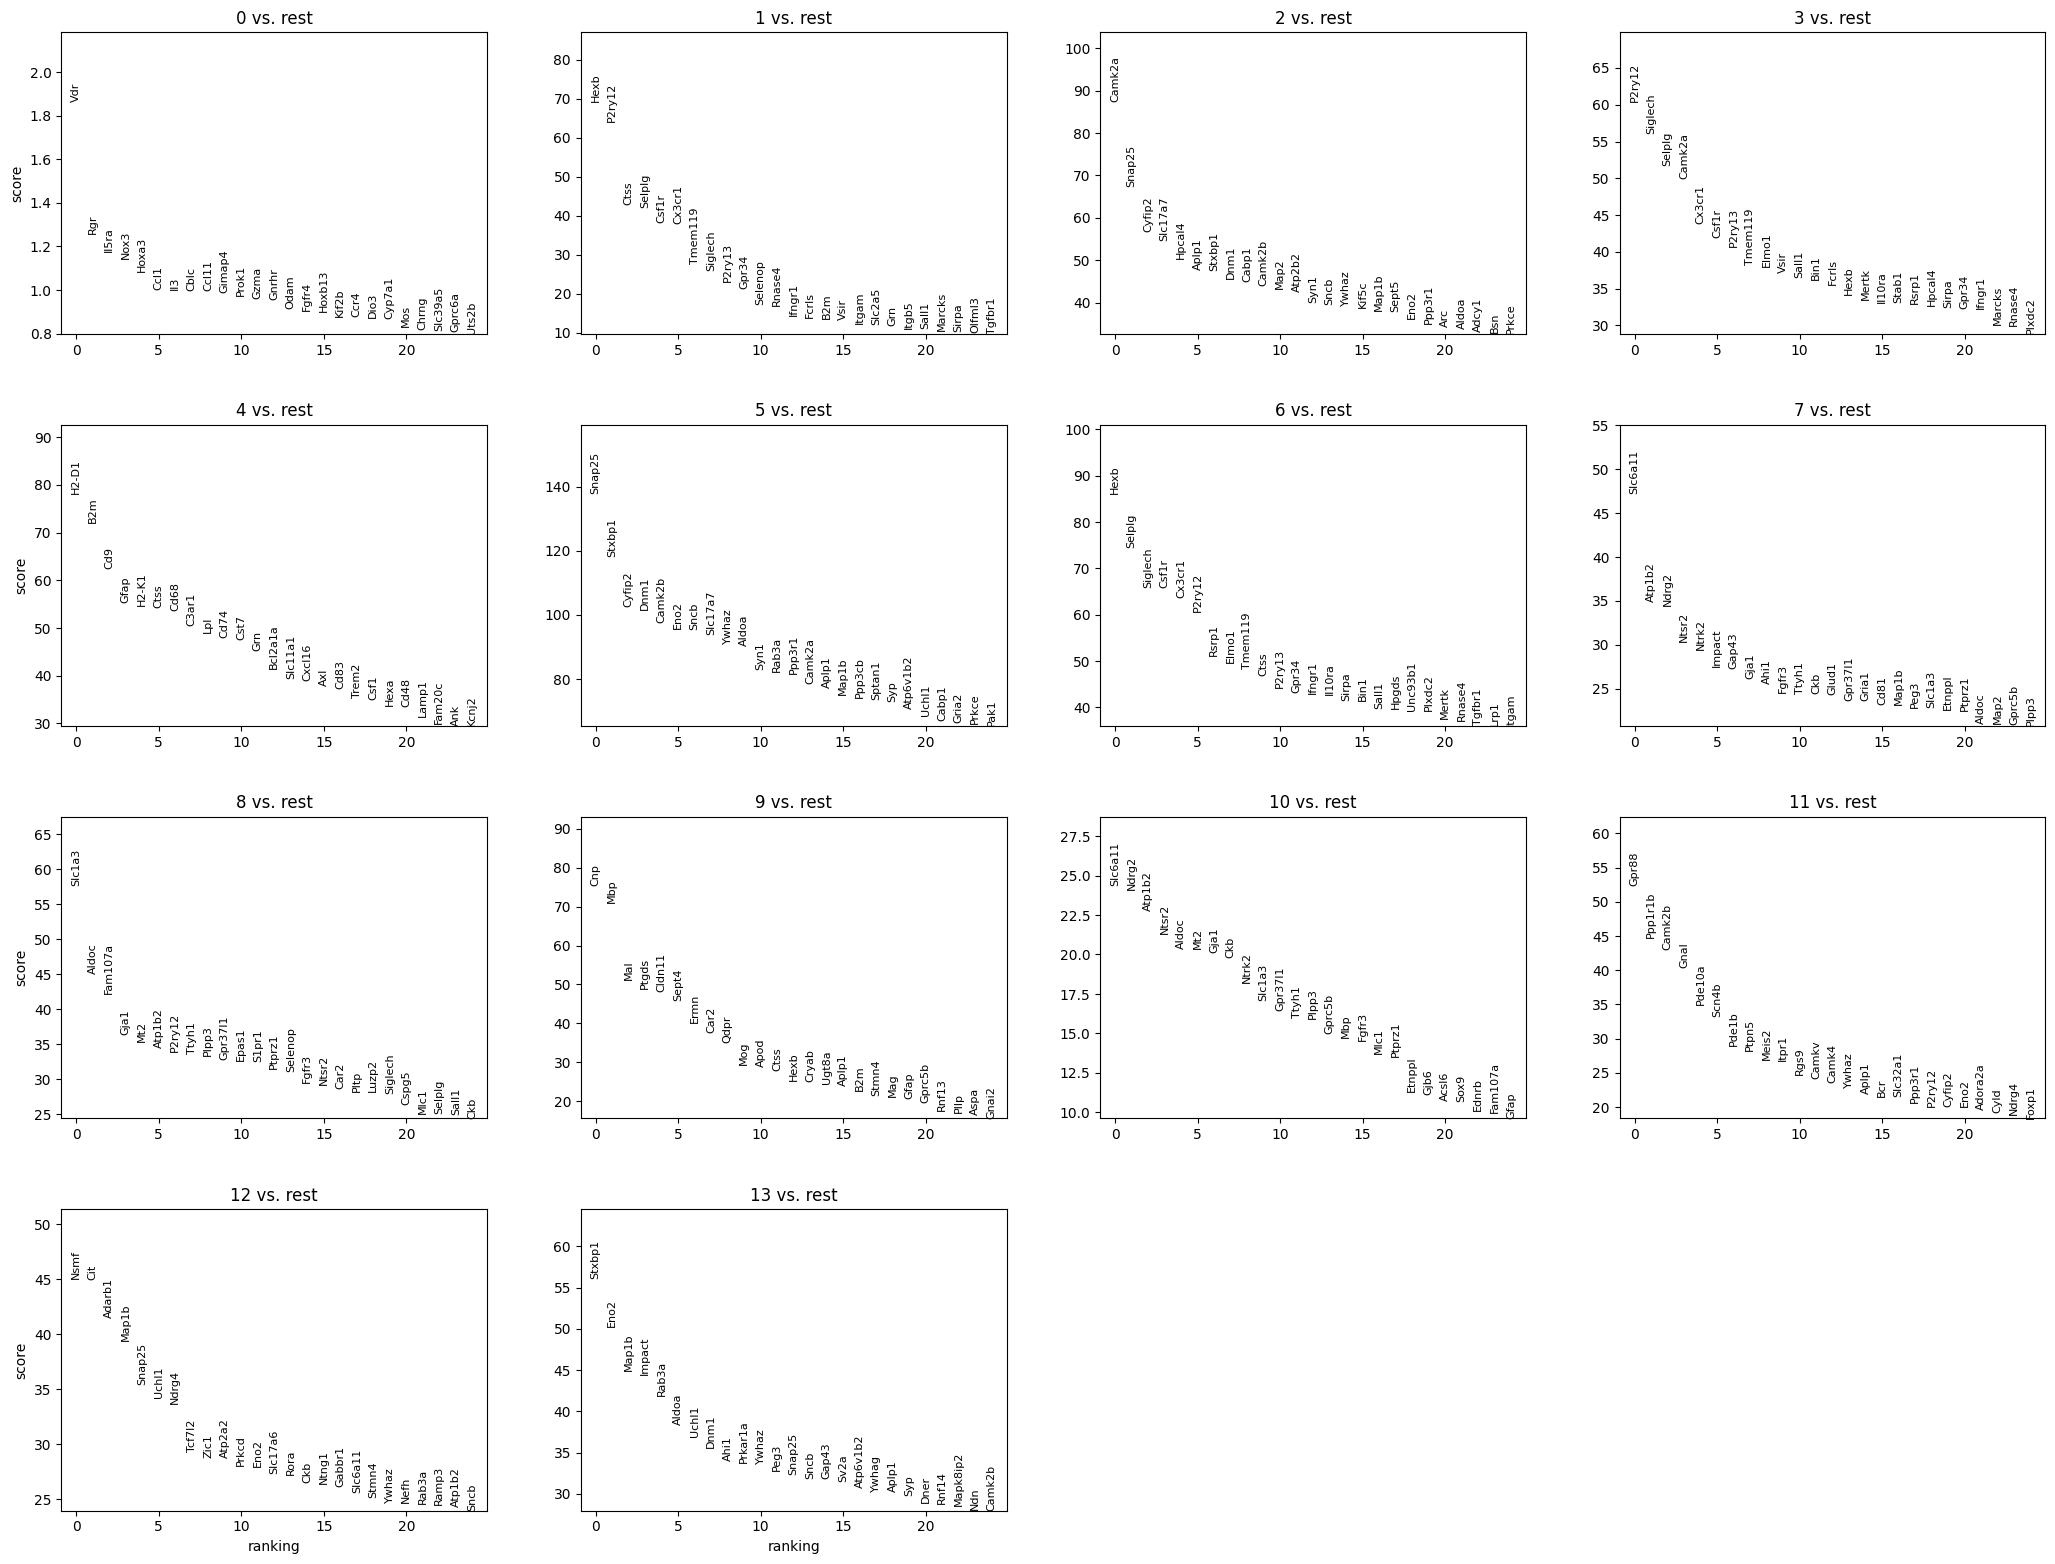

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Vdr,1.862803,2.135768,0.062561,0.072545
1,0,Rgr,1.255383,1.926750,0.209411,0.229032
2,0,Il5ra,1.175046,2.628314,0.240045,0.261639
3,0,Nox3,1.141166,2.427246,0.253868,0.276233
4,0,Hoxa3,1.083008,2.147577,0.278869,0.302855


In [15]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata_mic, groupby="micro_leiden_1.0", method="t-test")
sc.pl.rank_genes_groups(adata_mic, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata_mic, group=None)
markers.head()

In [17]:
import pandas as pd

In [24]:
marker_genes = pd.DataFrame({
    group: adata_mic.uns['rank_genes_groups']['names'][group][:10]
    for group in adata_mic.uns['rank_genes_groups']['names'].dtype.names
})
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

0
Vdr Rgr Il5ra Nox3 Hoxa3 Ccl1 Il3 Cblc Ccl11 Gimap4
 
1
Hexb P2ry12 Ctss Selplg Csf1r Cx3cr1 Tmem119 Siglech P2ry13 Gpr34
 
2
Camk2a Snap25 Cyfip2 Slc17a7 Hpcal4 Aplp1 Stxbp1 Dnm1 Cabp1 Camk2b
 
3
P2ry12 Siglech Selplg Camk2a Cx3cr1 Csf1r P2ry13 Tmem119 Elmo1 Vsir
 
4
H2-D1 B2m Cd9 Gfap H2-K1 Ctss Cd68 C3ar1 Lpl Cd74
 
5
Snap25 Stxbp1 Cyfip2 Dnm1 Camk2b Eno2 Sncb Slc17a7 Ywhaz Aldoa
 
6
Hexb Selplg Siglech Csf1r Cx3cr1 P2ry12 Rsrp1 Elmo1 Tmem119 Ctss
 
7
Slc6a11 Atp1b2 Ndrg2 Ntsr2 Ntrk2 Impact Gap43 Gja1 Ahi1 Fgfr3
 
8
Slc1a3 Aldoc Fam107a Gja1 Mt2 Atp1b2 P2ry12 Ttyh1 Plpp3 Gpr37l1
 
9
Cnp Mbp Mal Ptgds Cldn11 Sept4 Ermn Car2 Qdpr Mog
 
10
Slc6a11 Ndrg2 Atp1b2 Ntsr2 Aldoc Mt2 Gja1 Ckb Ntrk2 Slc1a3
 
11
Gpr88 Ppp1r1b Camk2b Gnal Pde10a Scn4b Pde1b Ptpn5 Meis2 Itpr1
 
12
Nsmf Cit Adarb1 Map1b Snap25 Uchl1 Ndrg4 Tcf7l2 Zic1 Atp2a2
 
13
Stxbp1 Eno2 Map1b Impact Rab3a Aldoa Uchl1 Dnm1 Ahi1 Prkar1a
 


In [18]:
marker_genes = pd.DataFrame({
    group: adata_mic.uns['rank_genes_groups']['names'][group][:4]
    for group in adata_mic.uns['rank_genes_groups']['names'].dtype.names
})


In [19]:
cellclass_markers_top4 = {}
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')
    cellclass_markers_top4[col] = genes

0
Vdr Rgr Il5ra Nox3
 
1
Hexb P2ry12 Ctss Selplg
 
2
Camk2a Snap25 Cyfip2 Slc17a7
 
3
P2ry12 Siglech Selplg Camk2a
 
4
H2-D1 B2m Cd9 Gfap
 
5
Snap25 Stxbp1 Cyfip2 Dnm1
 
6
Hexb Selplg Siglech Csf1r
 
7
Slc6a11 Atp1b2 Ndrg2 Ntsr2
 
8
Slc1a3 Aldoc Fam107a Gja1
 
9
Cnp Mbp Mal Ptgds
 
10
Slc6a11 Ndrg2 Atp1b2 Ntsr2
 
11
Gpr88 Ppp1r1b Camk2b Gnal
 
12
Nsmf Cit Adarb1 Map1b
 
13
Stxbp1 Eno2 Map1b Impact
 


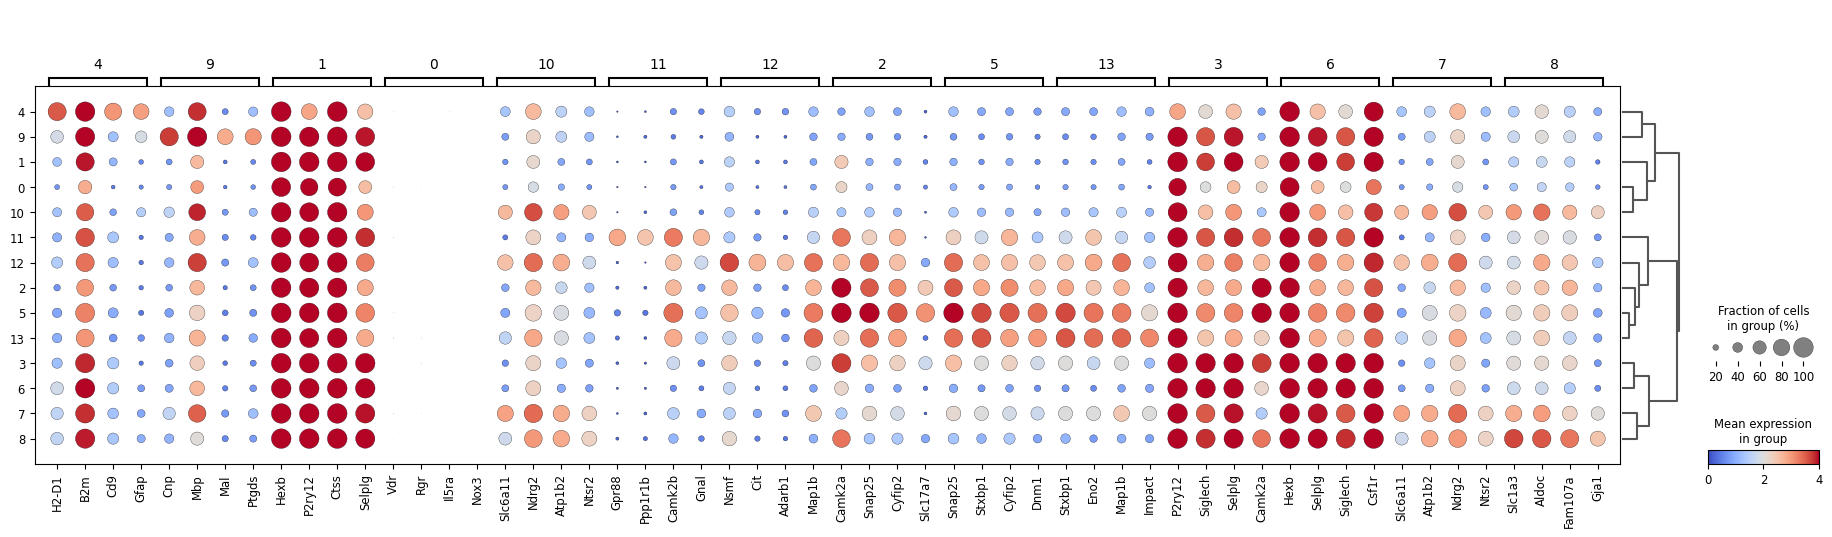

In [22]:
sc.pl.dotplot(
    adata_mic,
    var_names=cellclass_markers_top4,
    groupby="micro_leiden_1.0",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

In [95]:
# Updated microglia state marker panels (mouse)
panels = {
    "Homeostatic": [
        "P2ry12", "Tmem119", "Cx3cr1", "Hexb", "Sall1"
    ],
    
    # Core / stage 1 DAM (lipid metabolism, phagocytosis, Trem2–Apoe axis)
    "DAM/Activated": [
        "Lpl", "Cst7", "Trem2", "Itgax", "Serpina3n"
    ],
    
    # Type I interferon / antiviral signature
    "IFN-responsive": [
        "Irf7", "Isg15", "Stat1"
    ],
    
    # Antigen presentation and processing (expanded)
    "Antigen-present.": [
        "Cd74",      # invariant chain
        "H2-Ab1",    # MHC-II beta chain
        "H2-Aa",     # MHC-II alpha chain
        "H2-Eb1",    # MHC-II beta chain
        "H2-DMa",    # MHC-II peptide loading
        "Ciita",     # MHC-II transcriptional activator
        "Cd68",      # lysosomal protein
        "Ctss",      # Cathepsin S
        "Psmb8",     # immunoproteasome subunit
        "Psmb9"      # immunoproteasome subunit
    ],
    
    "Proliferative": [
        "Mki67", "Top2a", "Pcna"
    ],
    
    "Chemotaxis": [
        "Ccl2", "Tnf"
    ]
}

categories: 0, 1, 2, etc.
var_group_labels: Homeostatic, DAM/Activated, IFN-responsive, etc.


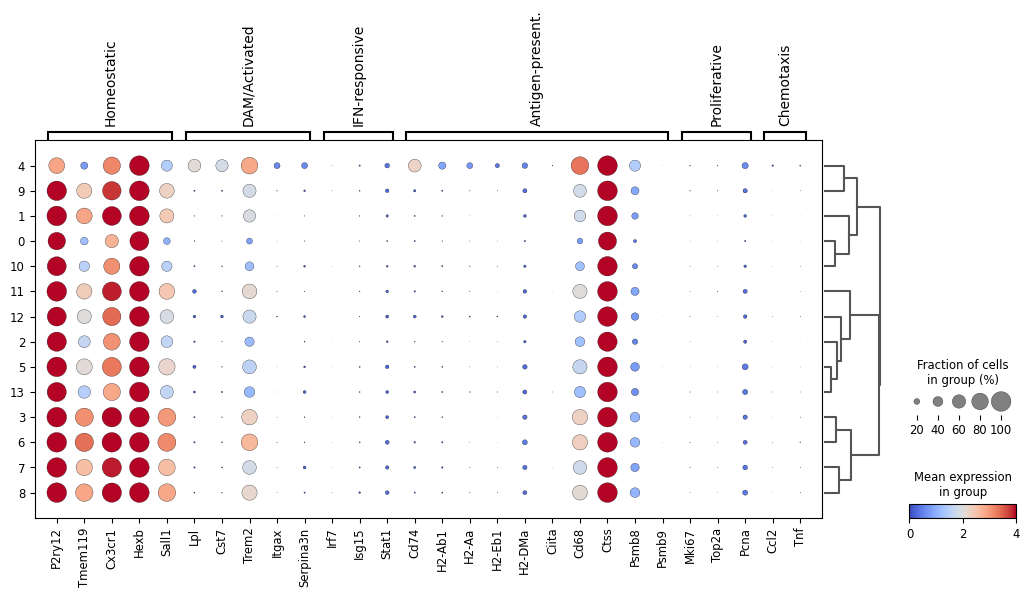

In [96]:
sc.pl.dotplot(
    adata_mic,
    var_names=panels,
    groupby="micro_leiden_1.0",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

In [97]:

def label_by_max_score(ad, group_key="micro_leiden_1.0", panels=panels):
    scores = {}
    for name, genes in panels.items():
        gs = [g for g in genes if g in ad.var_names]
        if not gs: 
            continue
        sc.tl.score_genes(ad, gs, score_name=f"score_{name}", use_raw=False)
        scores[name] = f"score_{name}"
    labels = {}
    for cl in ad.obs[group_key].cat.categories:
        sub = ad[ad.obs[group_key] == cl]
        means = {name: float(sub.obs[scol].mean()) for name, scol in scores.items()}
        labels[cl] = max(means, key=means.get) if means else "Unknown"
    return labels

labels = label_by_max_score(adata_mic)

In [98]:
adata_mic.obs["micro_state"] = adata_mic.obs["micro_leiden_1.0"].map(labels).astype("category")

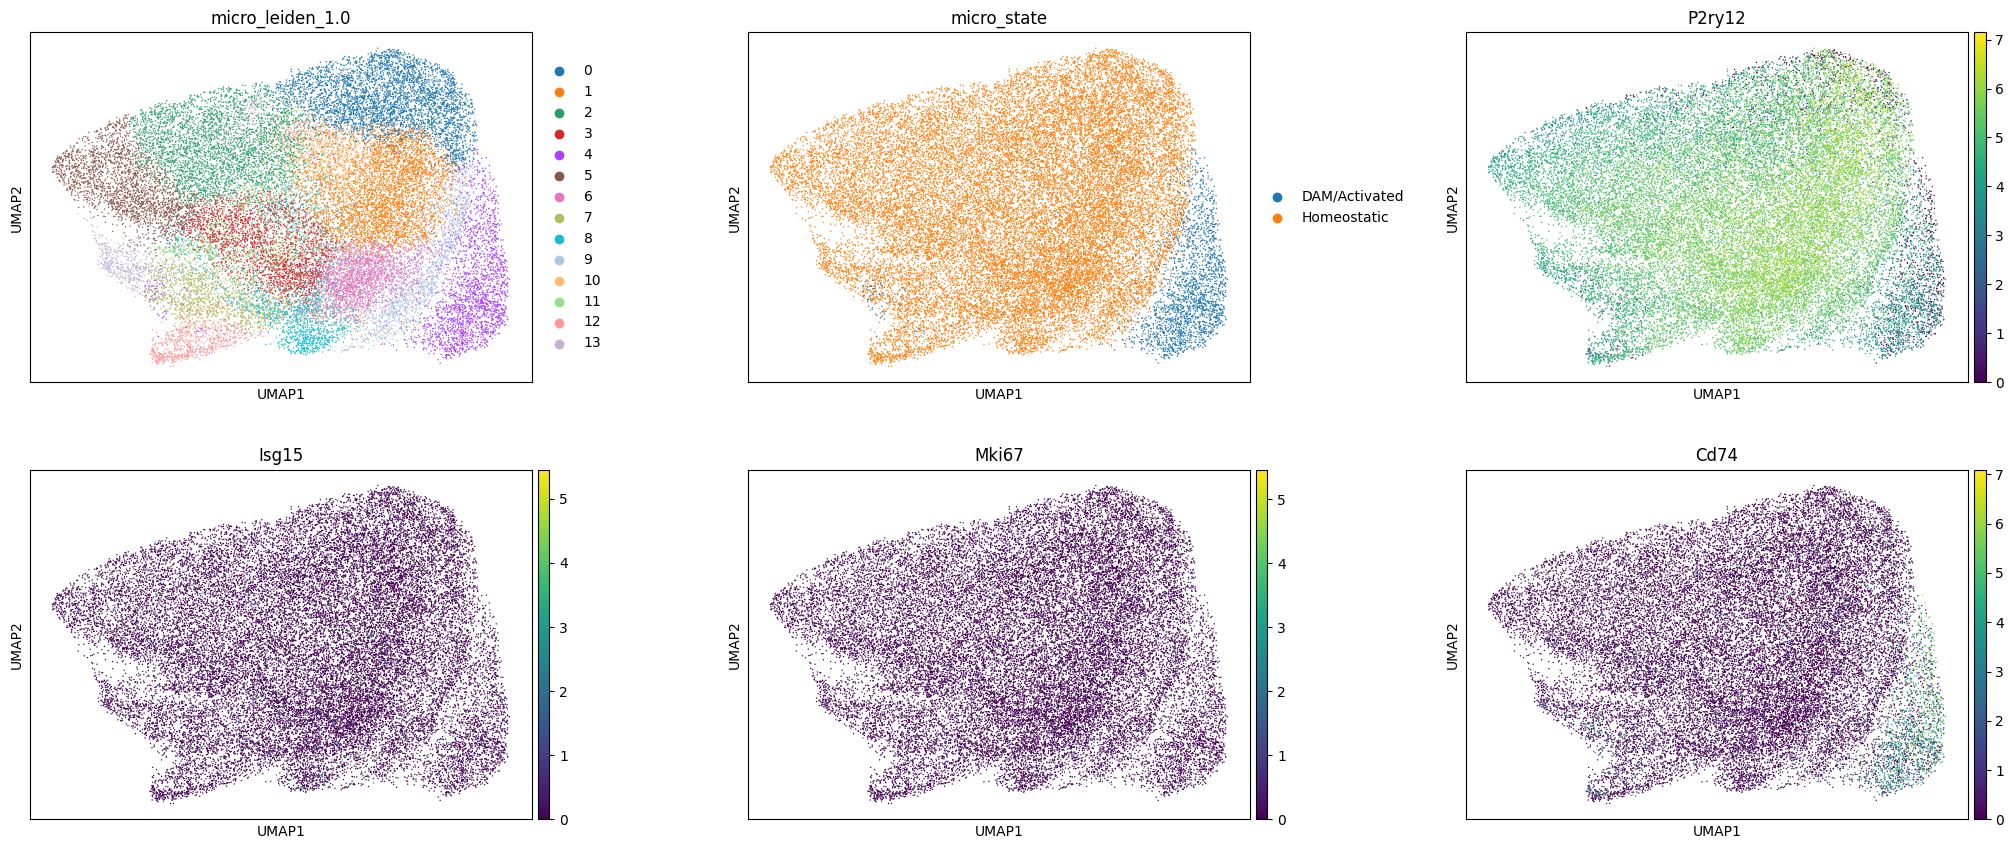

In [99]:
# ---------- 7) Plot ----------
sc.pl.umap(
    adata_mic, color=["micro_leiden_1.0","micro_state","P2ry12","Isg15","Mki67",'Cd74'],
    wspace=0.3, ncols=3
)


In [100]:
adata_mic[adata_mic.obs['micro_state'] == 'DAM/Activated'].obs.condition.value_counts()

condition
mtDSB      2108
control     172
Name: count, dtype: int64

In [101]:
dict(zip(adata_mic.obs['sample_id'], adata_mic.obs['condition']))

{'RB4282': 'control',
 'RB4350': 'control',
 'RB4401': 'mtDSB',
 'RB4403': 'mtDSB',
 'RB4405': 'mtDSB',
 'RB4498': 'control',
 'RB4620': 'control',
 'RB4627': 'mtDSB',
 'RB4630': 'mtDSB',
 'RB4653': 'mtDSB',
 'RB4658': 'control',
 'RB4676': 'control'}

Plotting micro_state …


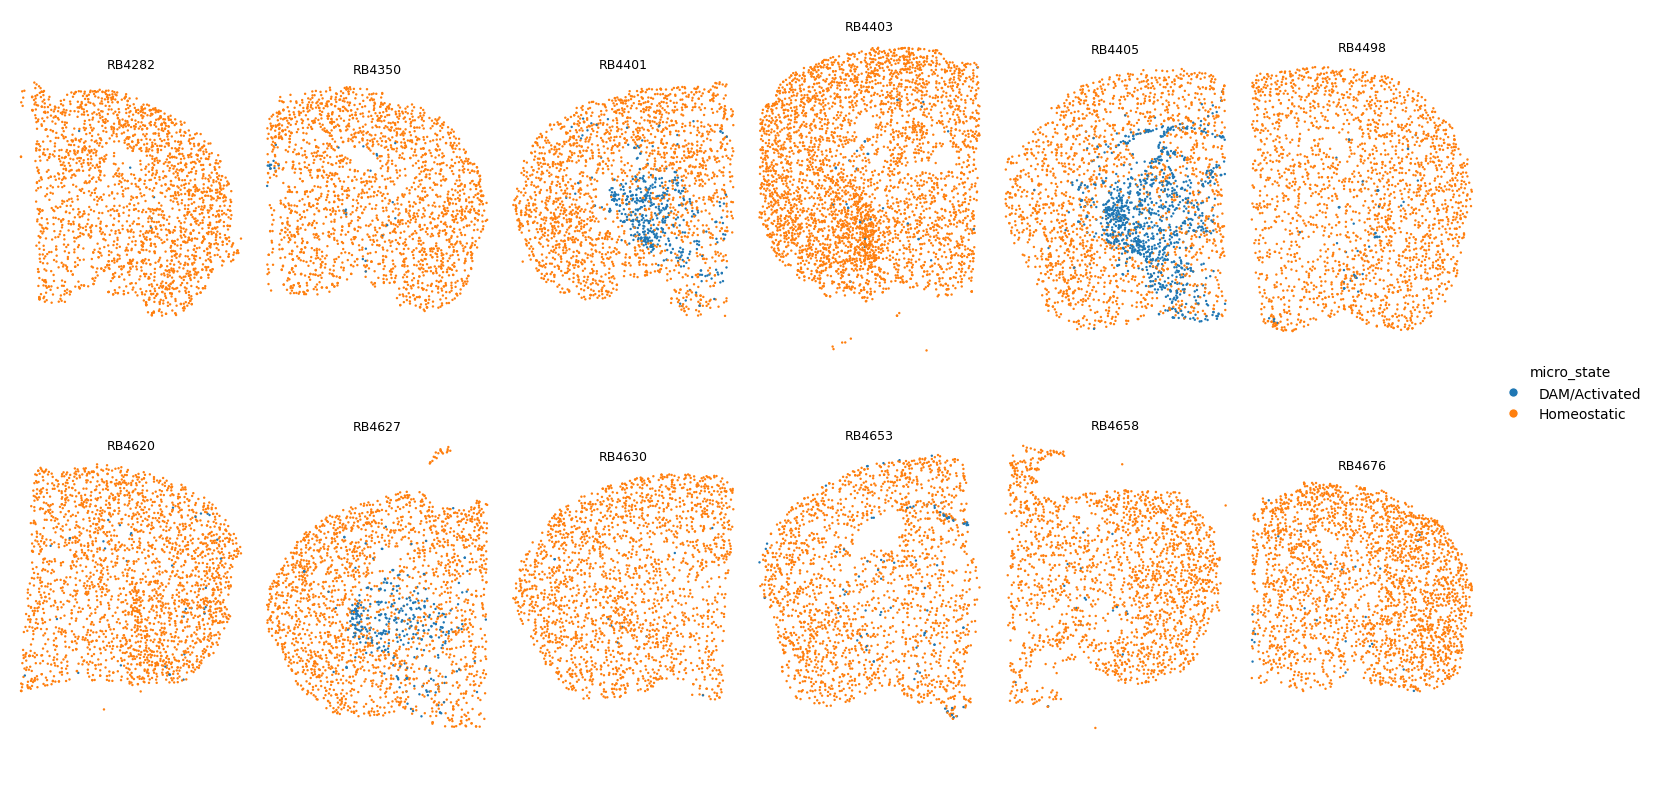

In [102]:
for domain in ['micro_state']:
    if domain in adata_mic.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata_mic,
            color=domain,
            groupby="sample_id",
            spot_size=3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")